# IMAGE - GENRATION - MODEL _ KRISHNA_GREAT💚🩶

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [4]:
transform = transforms.ToTensor()

train_data = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=transform
)

test_data = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_data,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_data,
    batch_size=64,
    shuffle=False
)

100%|██████████| 9.91M/9.91M [00:04<00:00, 2.13MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 132kB/s]
100%|██████████| 1.65M/1.65M [00:03<00:00, 416kB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 4.14MB/s]


In [5]:
class CNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=32,
            kernel_size=3
        )

        self.pool = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        self.conv2 = nn.Conv2d(
            in_channels=32,
            out_channels=64,
            kernel_size=3
        )

        self.fc1 = nn.Linear(
            64 * 5 * 5,
            128
        )

        self.fc2 = nn.Linear(
            128,
            10
        )

    def forward(self, x):

        x = self.conv1(x)
        x = torch.relu(x)
        x = self.pool(x)

        x = self.conv2(x)
        x = torch.relu(x)
        x = self.pool(x)

        x = x.view(x.size(0), -1)

        x = self.fc1(x)
        x = torch.relu(x)

        x = self.fc2(x)

        return x

In [7]:
model = CNN()

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [8]:
epochs = 5

for epoch in range(epochs):

    model.train()

    total_loss = 0

    for images, labels in train_loader:

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    print(
        f"Epoch {epoch + 1}/{epochs}, "
        f"Loss: {total_loss:.4f}"
    )

Epoch 1/5, Loss: 174.9496
Epoch 2/5, Loss: 50.8386
Epoch 3/5, Loss: 34.4008
Epoch 4/5, Loss: 27.2552
Epoch 5/5, Loss: 20.2629


In [9]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        outputs = model(images)

        _, predicted = torch.max(
            outputs,
            1
        )

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()

accuracy = 100 * correct / total

print(f"Accuracy: {accuracy:.2f}%")

Accuracy: 98.91%


# AutoEncoder 🛺

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader



In [11]:
transform = transforms.ToTensor()

train_data = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=transform
)

test_data = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_data,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_data,
    batch_size=64,
    shuffle=False
)

In [12]:
class Autoencoder(nn.Module):

    def __init__(self):
        super().__init__()

        # -------------------------
        # Encoder
        # -------------------------

        self.encoder = nn.Sequential(

            nn.Conv2d(
                in_channels=1,
                out_channels=32,
                kernel_size=3,
                stride=2,
                padding=1
            ),

            nn.ReLU(),

            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                stride=2,
                padding=1
            ),

            nn.ReLU()
        )

        # -------------------------
        # Decoder
        # -------------------------

        self.decoder = nn.Sequential(

            nn.ConvTranspose2d(
                in_channels=64,
                out_channels=32,
                kernel_size=3,
                stride=2,
                padding=1,
                output_padding=1
            ),

            nn.ReLU(),

            nn.ConvTranspose2d(
                in_channels=32,
                out_channels=1,
                kernel_size=3,
                stride=2,
                padding=1,
                output_padding=1
            ),

            nn.Sigmoid()
        )

    def forward(self, x):

        # Encode
        x = self.encoder(x)

        # Decode
        x = self.decoder(x)

        return x

In [13]:
model = Autoencoder()

print(model)

Autoencoder(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(64, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(32, 1, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (3): Sigmoid()
  )
)


In [14]:
criterion = nn.MSELoss()

In [15]:
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [17]:
epochs = 5

for epoch in range(epochs):

    model.train()

    total_loss = 0

    for images, _ in train_loader:

        # Forward pass
        reconstructed = model(images)

        # Compare original and reconstructed image
        loss = criterion(
            reconstructed,
            images
        )

        # Clear gradients
        optimizer.zero_grad()

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    print(
        f"Epoch [{epoch + 1}/{epochs}], "
        f"Loss: {avg_loss:.6f}"
    )

Epoch [1/5], Loss: 0.000254
Epoch [2/5], Loss: 0.000225
Epoch [3/5], Loss: 0.000203
Epoch [4/5], Loss: 0.000187
Epoch [5/5], Loss: 0.000175


In [18]:
import matplotlib.pyplot as plt

model.eval()

images, _ = next(iter(test_loader))

with torch.no_grad():
    reconstructed = model(images)

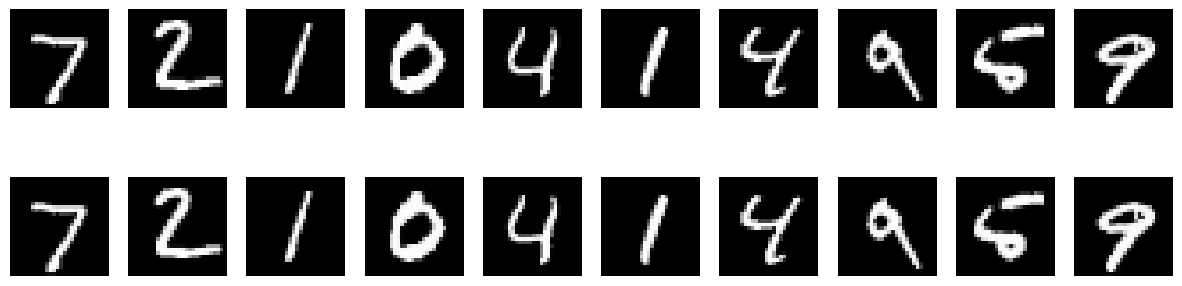

In [19]:
plt.figure(figsize=(15, 4))

for i in range(10):

    # Original
    ax = plt.subplot(2, 10, i + 1)

    plt.imshow(
        images[i].squeeze(),
        cmap="gray"
    )

    plt.axis("off")

    # Reconstructed
    ax = plt.subplot(
        2,
        10,
        i + 11
    )

    plt.imshow(
        reconstructed[i].squeeze(),
        cmap="gray"
    )

    plt.axis("off")

plt.show()

# VAE (Variational Autoencoder) 🔥

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [2]:
transform = transforms.ToTensor()

train_data = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=transform
)

test_data = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_data,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_data,
    batch_size=64,
    shuffle=False
)

In [3]:
class VAE(nn.Module):

    def __init__(self, latent_dim=20):

        super().__init__()

        self.latent_dim = latent_dim

        # =========================
        # Encoder
        # =========================

        self.encoder = nn.Sequential(

            nn.Conv2d(
                in_channels=1,
                out_channels=32,
                kernel_size=3,
                stride=2,
                padding=1
            ),

            nn.ReLU(),

            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                stride=2,
                padding=1
            ),

            nn.ReLU()
        )

        # 64 × 7 × 7 = 3136

        self.fc_mu = nn.Linear(
            64 * 7 * 7,
            latent_dim
        )

        self.fc_logvar = nn.Linear(
            64 * 7 * 7,
            latent_dim
        )

        # =========================
        # Decoder
        # =========================

        self.decoder_input = nn.Linear(
            latent_dim,
            64 * 7 * 7
        )

        self.decoder = nn.Sequential(

            nn.ConvTranspose2d(
                in_channels=64,
                out_channels=32,
                kernel_size=3,
                stride=2,
                padding=1,
                output_padding=1
            ),

            nn.ReLU(),

            nn.ConvTranspose2d(
                in_channels=32,
                out_channels=1,
                kernel_size=3,
                stride=2,
                padding=1,
                output_padding=1
            ),

            nn.Sigmoid()
        )

    # =========================
    # Encoder
    # =========================

    def encode(self, x):

        x = self.encoder(x)

        x = torch.flatten(
            x,
            start_dim=1
        )

        mu = self.fc_mu(x)

        logvar = self.fc_logvar(x)

        return mu, logvar

    # =========================
    # Reparameterization
    # =========================

    def reparameterize(self, mu, logvar):

        std = torch.exp(
            0.5 * logvar
        )

        eps = torch.randn_like(std)

        z = mu + eps * std

        return z

    # =========================
    # Decoder
    # =========================

    def decode(self, z):

        x = self.decoder_input(z)

        x = x.view(
            -1,
            64,
            7,
            7
        )

        x = self.decoder(x)

        return x

    # =========================
    # Forward
    # =========================

    def forward(self, x):

        mu, logvar = self.encode(x)

        z = self.reparameterize(
            mu,
            logvar
        )

        reconstructed = self.decode(z)

        return reconstructed, mu, logvar

In [4]:
model = VAE(latent_dim=20)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

print(model)

VAE(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
  )
  (fc_mu): Linear(in_features=3136, out_features=20, bias=True)
  (fc_logvar): Linear(in_features=3136, out_features=20, bias=True)
  (decoder_input): Linear(in_features=20, out_features=3136, bias=True)
  (decoder): Sequential(
    (0): ConvTranspose2d(64, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(32, 1, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (3): Sigmoid()
  )
)


In [5]:
for images, _ in train_loader:
    reconstructed, mu, logvar = model(images)

    reconstruction_loss = nn.functional.binary_cross_entropy(
        reconstructed,
        images,
        reduction='sum'
    )

    kl_loss = -0.5 * torch.sum(
        1 + logvar
        - mu.pow(2)
        - logvar.exp()
    )

    loss = reconstruction_loss + kl_loss

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    print(f"Loss: {loss.item():.4f}")
    break

Loss: 36453.3867


In [6]:
# This cell is now redundant; keep it empty or use it for later metrics.
pass

In [7]:
# Optional training loop for a few epochs
for epoch in range(20):
    model.train()
    total_loss = 0.0

    for images, _ in train_loader:
        reconstructed, mu, logvar = model(images)

        recon_loss = nn.functional.binary_cross_entropy(
            reconstructed,
            images,
            reduction='sum'
        )
        kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
        loss = recon_loss + kl_loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch + 1}/3, Loss: {total_loss / len(train_loader):.4f}")

Epoch 1/3, Loss: 9230.0291
Epoch 2/3, Loss: 7310.7433
Epoch 3/3, Loss: 7021.3836
Epoch 4/3, Loss: 6894.7466
Epoch 5/3, Loss: 6819.6143
Epoch 6/3, Loss: 6769.3069
Epoch 7/3, Loss: 6728.3415
Epoch 8/3, Loss: 6698.1655
Epoch 9/3, Loss: 6670.3918
Epoch 10/3, Loss: 6647.5126
Epoch 11/3, Loss: 6629.0469
Epoch 12/3, Loss: 6609.6125
Epoch 13/3, Loss: 6598.3618
Epoch 14/3, Loss: 6583.9652
Epoch 15/3, Loss: 6571.4161
Epoch 16/3, Loss: 6558.3200
Epoch 17/3, Loss: 6548.7351
Epoch 18/3, Loss: 6536.9889
Epoch 19/3, Loss: 6528.9169
Epoch 20/3, Loss: 6520.4329


In [8]:
import matplotlib.pyplot as plt

model.eval()

images, _ = next(iter(test_loader))

with torch.no_grad():

    reconstructed, _, _ = model(images)

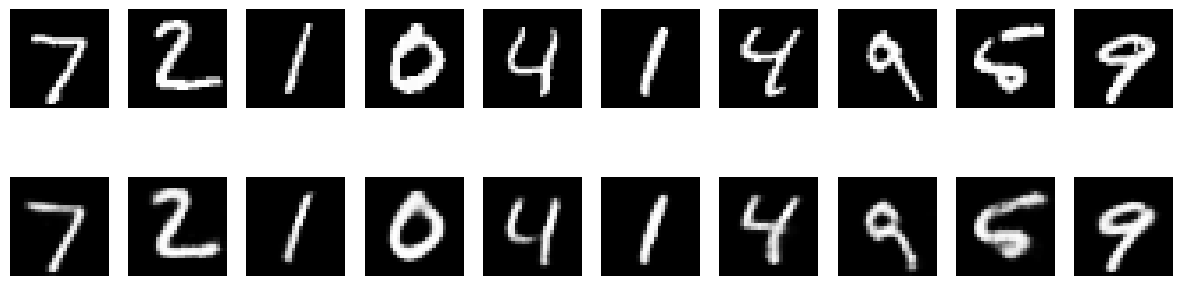

In [9]:
plt.figure(figsize=(15, 4))

for i in range(10):

    # Original
    plt.subplot(2, 10, i + 1)

    plt.imshow(
        images[i].squeeze(),
        cmap="gray"
    )

    plt.axis("off")

    # Reconstruction
    plt.subplot(
        2,
        10,
        i + 11
    )

    plt.imshow(
        reconstructed[i].squeeze(),
        cmap="gray"
    )

    plt.axis("off")

plt.show()

In [10]:
z = torch.randn(
    16,
    20
)

In [11]:
with torch.no_grad():

    generated = model.decode(z)

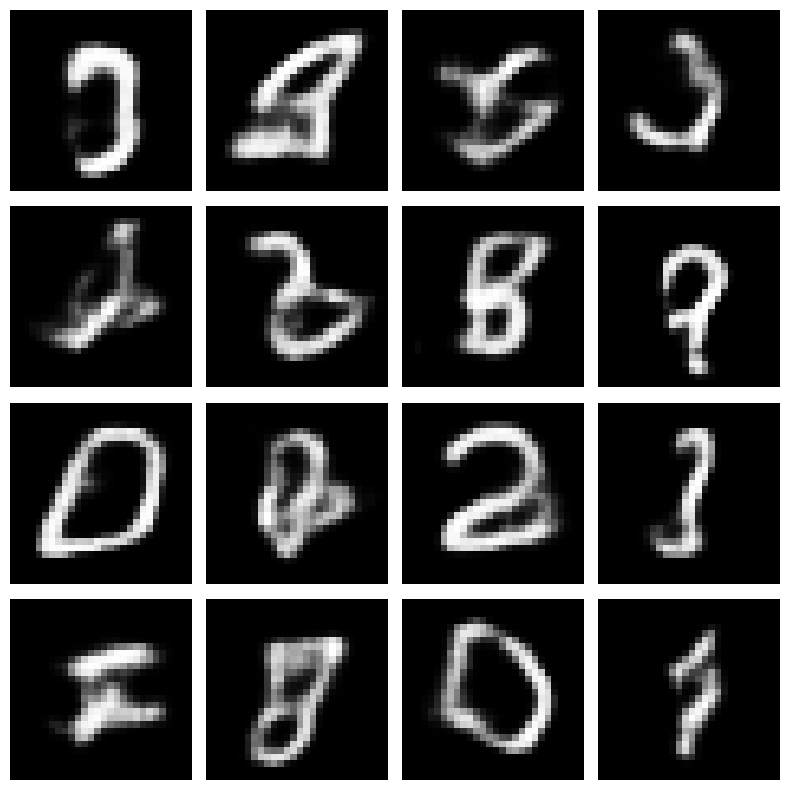

In [12]:
plt.figure(figsize=(8, 8))

for i in range(16):

    plt.subplot(4, 4, i + 1)

    plt.imshow(
        generated[i].squeeze(),
        cmap="gray"
    )

    plt.axis("off")

plt.tight_layout()

plt.show()

# GAN (Generative Adversarial Network) 🪿

GAN mein do neural networks hote hain:
Generator 🏭

Fake images banata hai.

Discriminator 🕵️

Decide karta hai: real or fake

Generator ka goal:

Discriminator ko fool karna.

Discriminator ka goal:

Fake ko identify karna.

| VAE                              | GAN                            |
| -------------------------------- | ------------------------------ |
| Encoder + Decoder                | Generator + Discriminator      |
| Probability-based latent space   | Adversarial training           |
| Reconstruction loss + KL         | Generator + Discriminator loss |
| Usually smoother/blurrier output | Sharper outputs possible       |
| Sampling easy                    | Training harder                |




# GAN Architecture🏹

## Generator

Random Noise
    ↓
100 values
    ↓
Linear
    ↓
256
    ↓
512
    ↓
784
    ↓
28 × 28
    ↓
Image

## Discriminator

28 × 28 Image
      ↓
    Flatten
      ↓
    512
      ↓
    256
      ↓
     1
      ↓
Real / Fake

In [13]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

In [14]:
transform = transforms.ToTensor()

train_data = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_data,
    batch_size=64,
    shuffle=True
)

In [15]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Using:", device)

Using: cpu


In [16]:
class Generator(nn.Module):

    def __init__(self, noise_dim=100):

        super().__init__()

        self.model = nn.Sequential(

            nn.Linear(
                noise_dim,
                256
            ),

            nn.LeakyReLU(0.2),

            nn.Linear(
                256,
                512
            ),

            nn.LeakyReLU(0.2),

            nn.Linear(
                512,
                1024
            ),

            nn.LeakyReLU(0.2),

            nn.Linear(
                1024,
                784
            ),

            nn.Tanh()
        )

    def forward(self, z):

        img = self.model(z)

        img = img.view(
            z.size(0),
            1,
            28,
            28
        )

        return img

In [17]:
class Discriminator(nn.Module):

    def __init__(self):

        super().__init__()

        self.model = nn.Sequential(

            nn.Linear(
                784,
                512
            ),

            nn.LeakyReLU(0.2),

            nn.Linear(
                512,
                256
            ),

            nn.LeakyReLU(0.2),

            nn.Linear(
                256,
                1
            ),

            nn.Sigmoid()
        )

    def forward(self, img):

        img = img.view(
            img.size(0),
            -1
        )

        return self.model(img)

In [18]:
noise_dim = 100

generator = Generator(
    noise_dim
).to(device)

discriminator = Discriminator().to(device)

In [19]:
criterion = nn.BCELoss()

In [20]:
optimizer_G = optim.Adam(
    generator.parameters(),
    lr=0.0002,
    betas=(0.5, 0.999)
)

optimizer_D = optim.Adam(
    discriminator.parameters(),
    lr=0.0002,
    betas=(0.5, 0.999)
)

In [24]:
epochs = 50

for epoch in range(epochs):

    for real_images, _ in train_loader:

        batch_size = real_images.size(0)

        real_images = real_images.to(device)

        # ==================================
        # Train Discriminator
        # ==================================

        noise = torch.randn(
            batch_size,
            noise_dim,
            device=device
        )

        fake_images = generator(noise)

        real_labels = torch.ones(
            batch_size,
            1,
            device=device
        )

        fake_labels = torch.zeros(
            batch_size,
            1,
            device=device
        )

        # Real images
        real_output = discriminator(
            real_images
        )

        loss_real = criterion(
            real_output,
            real_labels
        )

        # Fake images
        fake_output = discriminator(
            fake_images.detach()
        )

        loss_fake = criterion(
            fake_output,
            fake_labels
        )

        # Total discriminator loss
        loss_D = loss_real + loss_fake

        optimizer_D.zero_grad()

        loss_D.backward()

        optimizer_D.step()

        # ==================================
        # Train Generator
        # ==================================

        noise = torch.randn(
            batch_size,
            noise_dim,
            device=device
        )

        fake_images = generator(noise)

        fake_output = discriminator(
            fake_images
        )

        # Generator wants discriminator
        # to think fake images are REAL

        loss_G = criterion(
            fake_output,
            real_labels
        )

        optimizer_G.zero_grad()

        loss_G.backward()

        optimizer_G.step()

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Loss D: {loss_D.item():.4f} "
        f"Loss G: {loss_G.item():.4f}"
    )

Epoch [1/50] Loss D: 0.3644 Loss G: 2.4762
Epoch [2/50] Loss D: 0.5237 Loss G: 2.2294
Epoch [3/50] Loss D: 1.0350 Loss G: 5.3953
Epoch [4/50] Loss D: 0.5162 Loss G: 2.8943
Epoch [5/50] Loss D: 0.4524 Loss G: 3.1936
Epoch [6/50] Loss D: 0.4441 Loss G: 2.5931
Epoch [7/50] Loss D: 0.3407 Loss G: 3.0866
Epoch [8/50] Loss D: 0.5048 Loss G: 1.8271
Epoch [9/50] Loss D: 0.4069 Loss G: 2.1959
Epoch [10/50] Loss D: 0.5967 Loss G: 3.7765
Epoch [11/50] Loss D: 0.5741 Loss G: 2.5375
Epoch [12/50] Loss D: 0.6288 Loss G: 3.7188
Epoch [13/50] Loss D: 0.4632 Loss G: 2.4844
Epoch [14/50] Loss D: 0.4949 Loss G: 3.1621
Epoch [15/50] Loss D: 0.3997 Loss G: 2.6011
Epoch [16/50] Loss D: 0.5141 Loss G: 3.5219
Epoch [17/50] Loss D: 0.5182 Loss G: 1.4201
Epoch [18/50] Loss D: 0.5093 Loss G: 4.4957
Epoch [19/50] Loss D: 0.4450 Loss G: 1.7252
Epoch [20/50] Loss D: 0.4327 Loss G: 2.8609
Epoch [21/50] Loss D: 0.5080 Loss G: 3.1024
Epoch [22/50] Loss D: 0.5435 Loss G: 5.1805
Epoch [23/50] Loss D: 0.3999 Loss G: 2.97

In [25]:
generator.eval()

noise = torch.randn(
    16,
    noise_dim,
    device=device
)

with torch.no_grad():

    generated_images = generator(
        noise
    )

generated_images = (
    generated_images.cpu() + 1
) / 2

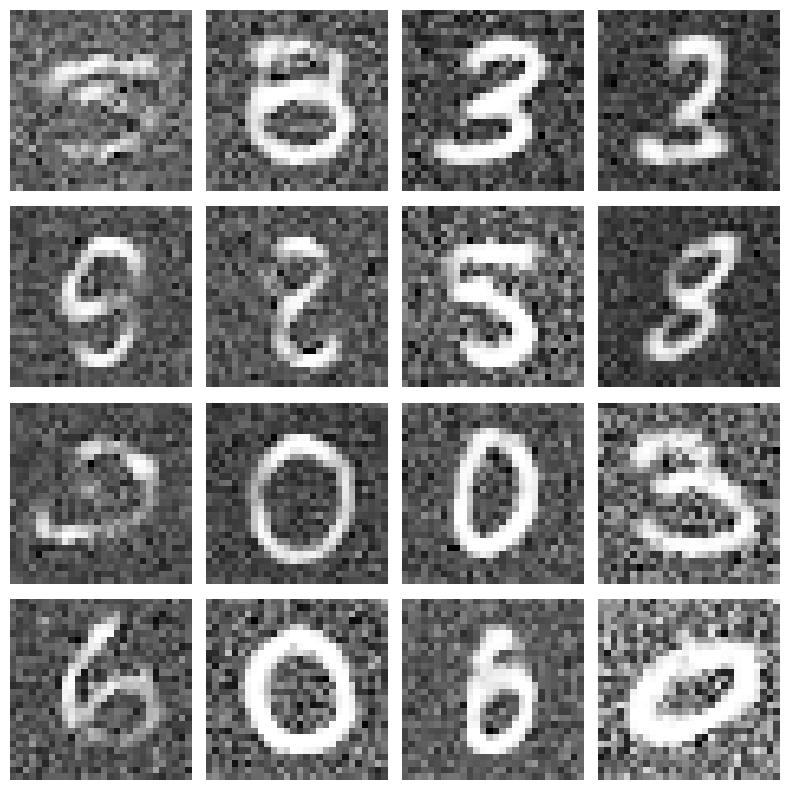

In [26]:
plt.figure(figsize=(8, 8))

for i in range(16):

    plt.subplot(4, 4, i + 1)

    plt.imshow(
        generated_images[i].squeeze(),
        cmap="gray"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

# Diffusion Model ☯️

Diffusion model random noise se gradually meaningful image generate karna seekhta hai.


Random Noise
     ↓
Denoising Step
     ↓
Denoising Step
     ↓
Denoising Step
     ↓
     ...
     ↓
Clean Image

Diffusion ke do processes samjho:

## Forward Process

Hum real image mein gradually noise add karte hain.
Original Image
      ↓
 + Noise
      ↓
More Noise
      ↓
More Noise
      ↓
Pure Noise

## Reverse Process

Model ko sikhate hain:

Pure Noise
    ↓
Remove Noise
    ↓
Remove Noise
    ↓
Remove Noise
    ↓
Clean Image

### Model ko noise remove karna sikhana.

In [27]:
'''

             TRAINING

Real Image
    │
    ▼
Add Noise ──────────────┐
    │                   │
    ▼                   │
Noisy Image              │
    │                   │
    ▼                   │
Noise Prediction Network │
    │                   │
    └──── predict noise ◄┘


             GENERATION

Random Noise
    │
    ▼
Noise Prediction Network
    │
    ▼
Remove Noise
    │
    ▼
Noise Prediction Network
    │
    ▼
Remove Noise
    │
    ▼
    ...
    │
    ▼
Clean Image 🖼️

'''

'\n\n             TRAINING\n\nReal Image\n    │\n    ▼\nAdd Noise ──────────────┐\n    │                   │\n    ▼                   │\nNoisy Image              │\n    │                   │\n    ▼                   │\nNoise Prediction Network │\n    │                   │\n    └──── predict noise ◄┘\n\n\n             GENERATION\n\nRandom Noise\n    │\n    ▼\nNoise Prediction Network\n    │\n    ▼\nRemove Noise\n    │\n    ▼\nNoise Prediction Network\n    │\n    ▼\nRemove Noise\n    │\n    ▼\n    ...\n    │\n    ▼\nClean Image 🖼️\n\n'

In [28]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

In [29]:
transform = transforms.ToTensor()

train_data = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_data,
    batch_size=64,
    shuffle=True
)

In [30]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print(device)

cpu


In [31]:
T = 1000

In [32]:
beta = torch.linspace(
    1e-4,
    0.02,
    T
).to(device)

In [34]:
alpha = 1.0 - beta

In [35]:
alpha_bar = torch.cumprod(
    alpha,
    dim=0
)

In [36]:
def add_noise(x_0, t):

    noise = torch.randn_like(x_0)

    sqrt_alpha_bar = torch.sqrt(
        alpha_bar[t]
    )

    sqrt_one_minus_alpha_bar = torch.sqrt(
        1 - alpha_bar[t]
    )

    sqrt_alpha_bar = sqrt_alpha_bar.view(
        -1, 1, 1, 1
    )

    sqrt_one_minus_alpha_bar = (
        sqrt_one_minus_alpha_bar.view(
            -1, 1, 1, 1
        )
    )

    x_t = (
        sqrt_alpha_bar * x_0
        +
        sqrt_one_minus_alpha_bar * noise
    )

    return x_t, noise

In [37]:
images, _ = next(iter(train_loader))

images = images[:8].to(device)

timesteps = torch.tensor(
    [0, 100, 200, 400, 600, 800, 900, 999],
    device=device
)

noisy_images = []

for i in range(8):

    img = images[i:i+1]

    t = timesteps[i:i+1]

    noisy, _ = add_noise(
        img,
        t
    )

    noisy_images.append(
        noisy.cpu()
    )

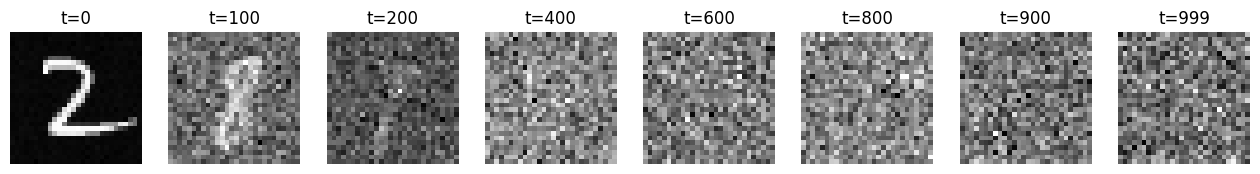

In [38]:
plt.figure(figsize=(16, 3))

for i in range(8):

    plt.subplot(
        1,
        8,
        i + 1
    )

    plt.imshow(
        noisy_images[i].squeeze(),
        cmap="gray"
    )

    plt.title(
        f"t={timesteps[i].item()}"
    )

    plt.axis("off")

plt.show()

In [39]:
class NoisePredictor(nn.Module):

    def __init__(self):

        super().__init__()

        self.model = nn.Sequential(

            nn.Conv2d(
                1,
                32,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.Conv2d(
                32,
                64,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.Conv2d(
                64,
                32,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.Conv2d(
                32,
                1,
                kernel_size=3,
                padding=1
            )
        )

    def forward(self, x, t):

        return self.model(x)

In [40]:
model = NoisePredictor().to(device)

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-3
)

criterion = nn.MSELoss()

In [41]:
epochs = 10

for epoch in range(epochs):

    model.train()

    total_loss = 0

    for images, _ in train_loader:

        images = images.to(device)

        batch_size = images.size(0)

        # Random timestep
        t = torch.randint(
            0,
            T,
            (batch_size,),
            device=device
        )

        # Add noise
        noisy_images, noise = add_noise(
            images,
            t
        )

        # Predict noise
        predicted_noise = model(
            noisy_images,
            t
        )

        # Loss
        loss = criterion(
            predicted_noise,
            noise
        )

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    avg_loss = (
        total_loss / len(train_loader)
    )

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Loss: {avg_loss:.4f}"
    )

Epoch [1/10] Loss: 0.0758
Epoch [2/10] Loss: 0.0415
Epoch [3/10] Loss: 0.0374
Epoch [4/10] Loss: 0.0350
Epoch [5/10] Loss: 0.0335
Epoch [6/10] Loss: 0.0327
Epoch [7/10] Loss: 0.0319
Epoch [8/10] Loss: 0.0314
Epoch [9/10] Loss: 0.0310
Epoch [10/10] Loss: 0.0306


In [43]:
x = torch.randn(
    16,
    1,
    28,
    28
).to(device)

for t in reversed(range(T)):

    predicted_noise = model(
        x,
        torch.full(
            (16,),
            t,
            device=device
        )
    )

x

tensor([[[[-0.3294,  0.4236, -0.6342,  ...,  0.5897, -0.8429, -1.7005],
          [-0.3788,  1.6264, -0.7198,  ...,  0.4579, -0.0508, -0.4577],
          [ 0.5104, -0.5336,  0.1655,  ..., -0.0846, -0.0803, -1.2368],
          ...,
          [-0.3658,  1.5051,  0.0201,  ..., -0.0115,  0.4306,  0.5555],
          [ 0.0350,  0.0921,  0.0843,  ...,  0.8946,  1.1362,  0.5540],
          [-2.3237, -0.8235,  0.4863,  ..., -0.0456,  0.0064, -0.4982]]],


        [[[-0.2109,  1.7362, -1.4547,  ..., -0.5525,  1.2505,  2.3353],
          [ 0.7899,  0.0237, -0.0998,  ..., -1.3515,  0.5616,  0.7433],
          [ 0.6649,  0.2464,  0.9496,  ...,  0.3092,  0.7747, -0.2618],
          ...,
          [ 0.0863,  1.1283, -0.2533,  ...,  1.0713, -1.3154, -0.2402],
          [ 1.0879, -0.2200,  0.6776,  ...,  0.4402, -0.7809,  0.6526],
          [-1.0548,  1.3136, -0.4948,  ...,  0.2837,  0.2457, -0.0813]]],


        [[[ 0.1969,  0.0288,  1.3682,  ...,  0.5448,  0.8590,  2.3561],
          [ 0.9157, -1.075

# U-Net
U-Net ek neural-network architecture hai jiska basic idea:


Image
  ↓
ENCODER
  ↓
Compressed representation
  ↓
DECODER
  ↓
Output


## Skip Connections 🔥

              ENCODER
                 ↓
Image → [Block] → [Block] → [Bottleneck]
          │                    │
          │                    ↓
          └────────────────→ [Block]
                               ↓
          └────────────────→ [Block]
                               ↓
                            Output




             ┌───────────────┐
             │ Encoder Block │
             └───────┬───────┘
                     │
             ┌───────▼───────┐
             │ Encoder Block │
             └───────┬───────┘
                     │
                     ▼
                 Bottleneck
                     │
             ┌───────▼───────┐
             │ Decoder Block │
             └───────┬───────┘
                     │
             ┌───────▼───────┐
             │ Decoder Block │
             └───────┬───────┘
                     │
                   Output



                   

# U-Net architecture

In [44]:
'''

INPUT
1 × 28 × 28
     │
     ▼
Conv Block
32 × 28 × 28
     │
     ├───────────────┐
     ▼               │
Downsample           │
32 × 14 × 14         │
     │               │
     ▼               │
Conv Block            │
64 × 14 × 14          │
     │               │
     ├───────────────┐│
     ▼               ││
Downsample           ││
64 × 7 × 7           ││
     │               ││
     ▼               ││
Bottleneck            ││
     │               ││
     ▼               ││
Upsample              ││
64 × 14 × 14          ││
     │               ││
     └──────┬────────┘│
            ▼         │
         Skip +       │
         Decoder      │
            │         │
            ▼         │
         Upsample     │
            │         │
            └─────────┘
                 ↓
          1 × 28 × 28

'''

'\n\nINPUT\n1 × 28 × 28\n     │\n     ▼\nConv Block\n32 × 28 × 28\n     │\n     ├───────────────┐\n     ▼               │\nDownsample           │\n32 × 14 × 14         │\n     │               │\n     ▼               │\nConv Block            │\n64 × 14 × 14          │\n     │               │\n     ├───────────────┐│\n     ▼               ││\nDownsample           ││\n64 × 7 × 7           ││\n     │               ││\n     ▼               ││\nBottleneck            ││\n     │               ││\n     ▼               ││\nUpsample              ││\n64 × 14 × 14          ││\n     │               ││\n     └──────┬────────┘│\n            ▼         │\n         Skip +       │\n         Decoder      │\n            │         │\n            ▼         │\n         Upsample     │\n            │         │\n            └─────────┘\n                 ↓\n          1 × 28 × 28\n\n'

In [45]:
import torch
import torch.nn as nn


class ConvBlock(nn.Module):

    def __init__(self, in_channels, out_channels):

        super().__init__()

        self.block = nn.Sequential(

            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU()
        )

    def forward(self, x):

        return self.block(x)

In [46]:
class UNet(nn.Module):

    def __init__(self):

        super().__init__()

        # -------------------------
        # Encoder
        # -------------------------

        self.enc1 = ConvBlock(
            1,
            32
        )

        self.pool1 = nn.MaxPool2d(
            2
        )

        self.enc2 = ConvBlock(
            32,
            64
        )

        self.pool2 = nn.MaxPool2d(
            2
        )

        # -------------------------
        # Bottleneck
        # -------------------------

        self.bottleneck = ConvBlock(
            64,
            128
        )

        # -------------------------
        # Decoder
        # -------------------------

        self.up2 = nn.ConvTranspose2d(
            128,
            64,
            kernel_size=2,
            stride=2
        )

        self.dec2 = ConvBlock(
            128,
            64
        )

        self.up1 = nn.ConvTranspose2d(
            64,
            32,
            kernel_size=2,
            stride=2
        )

        self.dec1 = ConvBlock(
            64,
            32
        )

        # -------------------------
        # Output
        # -------------------------

        self.output = nn.Conv2d(
            32,
            1,
            kernel_size=1
        )

    def forward(self, x):

        # Encoder
        e1 = self.enc1(x)

        p1 = self.pool1(e1)

        e2 = self.enc2(p1)

        p2 = self.pool2(e2)

        # Bottleneck
        b = self.bottleneck(p2)

        # Decoder
        d2 = self.up2(b)

        # Skip connection
        d2 = torch.cat(
            [d2, e2],
            dim=1
        )

        d2 = self.dec2(d2)

        d1 = self.up1(d2)

        # Skip connection
        d1 = torch.cat(
            [d1, e1],
            dim=1
        )

        d1 = self.dec1(d1)

        # Output
        out = self.output(d1)

        return out

In [47]:
model = UNet()

x = torch.randn(
    4,
    1,
    28,
    28
)

output = model(x)

print("Input :", x.shape)
print("Output:", output.shape)

Input : torch.Size([4, 1, 28, 28])
Output: torch.Size([4, 1, 28, 28])


# Attention Head
###  Attention model ko ye decide karne deta hai ki input ke kaunse parts ek doosre ke liye important hain.

# Self-Attention 🐍

In [48]:
import torch
import torch.nn as nn
import math

In [49]:
x = torch.randn(
    2,
    5,
    64
)

print(x.shape)

torch.Size([2, 5, 64])


In [50]:
class SelfAttention(nn.Module):

    def __init__(self, embed_dim):

        super().__init__()

        self.query = nn.Linear(
            embed_dim,
            embed_dim
        )

        self.key = nn.Linear(
            embed_dim,
            embed_dim
        )

        self.value = nn.Linear(
            embed_dim,
            embed_dim
        )

    def forward(self, x):

        Q = self.query(x)

        K = self.key(x)

        V = self.value(x)

        return Q, K, V

In [51]:
attention = SelfAttention(64)

Q, K, V = attention(x)

print(Q.shape)
print(K.shape)
print(V.shape)

torch.Size([2, 5, 64])
torch.Size([2, 5, 64])
torch.Size([2, 5, 64])


In [52]:
scores = torch.matmul(
    Q,
    K.transpose(-2, -1)
)

In [53]:
scores

tensor([[[-1.3931, -2.6753,  2.2199,  0.3061,  6.3577],
         [-1.2276,  3.9532, -0.7537,  0.3309, -1.6452],
         [ 3.3412, -0.6199,  1.6926,  0.8161,  3.1205],
         [-1.3959,  2.2439,  2.9150, -2.5598,  2.3449],
         [-0.3591,  7.1385, -2.6360,  3.7016, -4.0617]],

        [[-5.1916,  2.0619,  0.2027,  2.1625,  0.2009],
         [-1.4264,  2.0168,  2.3806, -3.3614, -3.0744],
         [-4.1237,  4.2787, -1.7578, -6.1443, -1.2653],
         [ 0.3465, -0.8910, -1.7792,  3.1342, -3.9278],
         [-3.8846,  0.7732,  2.7790, -3.5700, -5.0040]]],
       grad_fn=<UnsafeViewBackward0>)

In [ ]:
# scaling 

d_k = Q.size(-1)

scores = scores / math.sqrt(d_k)

In [55]:
# soft MAX

attention_weights = torch.softmax(
    scores,
    dim=-1
)

In [56]:
output = torch.matmul(
    attention_weights,
    V
)

print(output.shape)

torch.Size([2, 5, 64])


In [57]:
class SelfAttention(nn.Module):

    def __init__(self, embed_dim):

        super().__init__()

        self.query = nn.Linear(
            embed_dim,
            embed_dim
        )

        self.key = nn.Linear(
            embed_dim,
            embed_dim
        )

        self.value = nn.Linear(
            embed_dim,
            embed_dim
        )

        self.scale = math.sqrt(embed_dim)

    def forward(self, x):

        Q = self.query(x)

        K = self.key(x)

        V = self.value(x)

        scores = torch.matmul(
            Q,
            K.transpose(-2, -1)
        )

        scores = scores / self.scale

        weights = torch.softmax(
            scores,
            dim=-1
        )

        output = torch.matmul(
            weights,
            V
        )

        return output

In [59]:
attention = SelfAttention(
    embed_dim=64
)

x = torch.randn(
    2,
    5,
    64
)

output = attention(x)

print(output.shape)

torch.Size([2, 5, 64])


# Multi-Head Attention🤹‍♂️

In [60]:
'''
          Input
            ↓
 ┌──────────┼──────────┐
 ↓          ↓          ↓
Head 1    Head 2     Head 3
 ↓          ↓          ↓
Attention Attention Attention
 └──────────┼──────────┘
            ↓
       Concatenate
            ↓
       Linear Layer
'''

'\n          Input\n            ↓\n ┌──────────┼──────────┐\n ↓          ↓          ↓\nHead 1    Head 2     Head 3\n ↓          ↓          ↓\nAttention Attention Attention\n └──────────┼──────────┘\n            ↓\n       Concatenate\n            ↓\n       Linear Layer\n'

# Transformer

In [61]:
'''
Input
 ↓
Multi-Head Self-Attention
 ↓
Add & Norm
 ↓
Feed Forward Network
 ↓
Add & Norm
 ↓
Output
'''

'\nInput\n ↓\nMulti-Head Self-Attention\n ↓\nAdd & Norm\n ↓\nFeed Forward Network\n ↓\nAdd & Norm\n ↓\nOutput\n'

# Positional Encoding🧘

Ek important problem:

Attention ko naturally sequence order ka direct concept nahi milta.

Modern Transformers mein learned positional embeddings ya other positional methods use ho sakte hain.



# Diffusion se connection 🔥

Attention model ko image ke different regions ke relationships samajhne mein help karta hai.

In [62]:
'''
                    TEXT
                     ↓
               Text Encoder
                     ↓
              Text Embeddings
                     │
                     │
                     ▼
Random Noise → U-Net → Cross-Attention
                     │
                     ▼
                Denoising
                     │
                     ▼
                 Image 🖼️
'''

'\n                    TEXT\n                     ↓\n               Text Encoder\n                     ↓\n              Text Embeddings\n                     │\n                     │\n                     ▼\nRandom Noise → U-Net → Cross-Attention\n                     │\n                     ▼\n                Denoising\n                     │\n                     ▼\n                 Image 🖼️\n'

# Text-to-Image🗨️

In [ ]:
'''
              PROMPT
                 │
                 ▼
             Tokenizer
                 │
                 ▼
           Text Encoder
                 │
                 ▼
         Text Embeddings
                 │
                 │
                 ▼
Random Noise ──→ U-Net
                 │
                 │ ← Cross Attention
                 │
                 ▼
            Denoising
                 │
                 ▼
              Latent
                 │
                 ▼
              VAE
                 │
                 ▼
             IMAGE 🖼️
'''

In [63]:
import torch
import diffusers
import transformers

print("PyTorch:", torch.__version__)
print("Diffusers:", diffusers.__version__)
print("Transformers:", transformers.__version__)

PyTorch: 2.7.1+cpu
Diffusers: 0.34.0
Transformers: 4.55.4


In [64]:
from diffusers import DiffusionPipeline

In [68]:
import torch
from diffusers import DiffusionPipeline

device = "cuda" if torch.cuda.is_available() else "cpu"

pipe = DiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16 if device == "cuda" else torch.float32
)

pipe = pipe.to(device)

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

In [70]:
prompt = "A futuristic robot coding in a modern room"

image = pipe(
    prompt
).images[0]

image.save(
    r"C:\Users\great\OneDrive\Desktop\genrated.png"
)

  0%|          | 0/50 [00:00<?, ?it/s]